In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
import os

In [2]:
df = pd.read_csv("patients_cancer_poumon.csv")

df.head()

,patient_id,age,sexe_masculin,presence_nodule,subtilite_nodule,taille_nodule_px,x_nodule_norm,y_nodule_norm,tabagisme_paquets_annee,toux_chronique,dyspnee,douleur_thoracique,perte_poids,spo2,antecedent_familial,risque_malignite,classe_jsrt_source,diagnostic_source,cancer_image,image_path
0,JPCLN001,53,1,1,5,1,0.7979,0.3379,34.9,1,1,1,1,92,0,2,malin,malignant,1,jsrt_subset/malin/JPCLN001.jpg
1,JPCLN002,78,0,1,5,1,0.7881,0.5322,31.4,1,0,0,0,95,0,1,benin,benign,0,jsrt_subset/benin/JPCLN002.jpg
2,JPCLN003,63,0,1,5,1,0.6362,0.2183,34.9,1,1,1,1,92,1,2,malin,malignant,1,jsrt_subset/malin/JPCLN003.jpg
3,JPCLN004,68,0,1,5,1,0.2959,0.4082,28.4,1,0,0,0,95,0,1,benin,benign,0,jsrt_subset/benin/JPCLN004.jpg
4,JPCLN005,73,0,1,5,1,0.7021,0.3379,37.9,1,1,1,1,92,1,2,malin,malignant,1,jsrt_subset/malin/JPCLN005.jpg


In [5]:
df.info()
print("Nombre de lignes :", df.shape[0])
print("Nombre de colonnes :", df.shape[1])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 184 entries, 0 to 183
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   patient_id               184 non-null    object 
 1   age                      184 non-null    int64  
 2   sexe_masculin            184 non-null    int64  
 3   presence_nodule          184 non-null    int64  
 4   subtilite_nodule         184 non-null    int64  
 5   taille_nodule_px         184 non-null    int64  
 6   x_nodule_norm            184 non-null    float64
 7   y_nodule_norm            184 non-null    float64
 8   tabagisme_paquets_annee  184 non-null    float64
 9   toux_chronique           184 non-null    int64  
 10  dyspnee                  184 non-null    int64  
 11  douleur_thoracique       184 non-null    int64  
 12  perte_poids              184 non-null    int64  
 13  spo2                     184 non-null    int64  
 14  antecedent_familial      1

In [9]:
df.describe()

,age,sexe_masculin,presence_nodule,subtilite_nodule,taille_nodule_px,x_nodule_norm,y_nodule_norm,tabagisme_paquets_annee,toux_chronique,dyspnee,douleur_thoracique,perte_poids,spo2,antecedent_familial,risque_malignite,cancer_image
count,184.000000,184.000000,184.000000,184.000000,184.000000,184.000000,184.000000,184.000000,184.000000,184.000000,184.000000,184.000000,184.000000,184.000000,184.000000,184.000000
mean,59.331522,0.456522,0.836957,2.581522,0.836957,0.383059,0.354977,30.212500,0.836957,0.543478,0.543478,0.543478,93.858696,0.320652,1.380435,0.543478
std,12.770521,0.499465,0.370413,1.286281,0.370413,0.280274,0.224145,7.769606,0.370413,0.499465,0.499465,0.499465,2.254717,0.468001,0.751572,0.499465
min,21.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,9.000000,0.000000,0.000000,0.000000,0.000000,92.000000,0.000000,0.000000,0.000000
25%,51.000000,0.000000,1.000000,1.000000,1.000000,0.212925,0.195300,24.500000,1.000000,0.000000,0.000000,0.000000,92.000000,0.000000,1.000000,0.000000
50%,61.000000,0.000000,1.000000,3.000000,1.000000,0.289050,0.357900,31.400000,1.000000,1.000000,1.000000,1.000000,92.000000,0.000000,2.000000,1.000000
75%,69.000000,1.000000,1.000000,4.000000,1.000000,0.700675,0.520000,36.175000,1.000000,1.000000,1.000000,1.000000,95.000000,1.000000,2.000000,1.000000
max,80.000000,1.000000,1.000000,5.000000,1.000000,0.868200,0.828100,43.000000,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,2.000000,1.000000


In [8]:
df.isnull().sum()

patient_id                 0
age                        0
sexe_masculin              0
presence_nodule            0
subtilite_nodule           0
taille_nodule_px           0
x_nodule_norm              0
y_nodule_norm              0
tabagisme_paquets_annee    0
toux_chronique             0
dyspnee                    0
douleur_thoracique         0
perte_poids                0
spo2                       0
antecedent_familial        0
risque_malignite           0
classe_jsrt_source         0
diagnostic_source          0
cancer_image               0
image_path                 0
dtype: int64

In [10]:
df = df.dropna()

In [11]:
df.duplicated().sum()

0

In [ ]:
df = df.drop_duplicates()

In [12]:
print("Taille finale du dataset :", df.shape)

Taille finale du dataset : (184, 20)


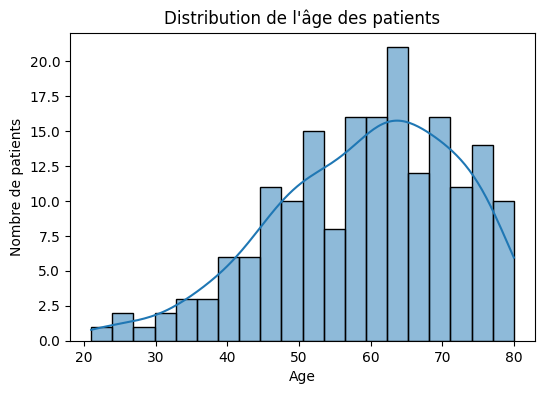

In [13]:
plt.figure(figsize=(6,4))
sns.histplot(df["age"], bins=20, kde=True)

plt.title("Distribution de l'âge des patients")
plt.xlabel("Age")
plt.ylabel("Nombre de patients")

plt.show()

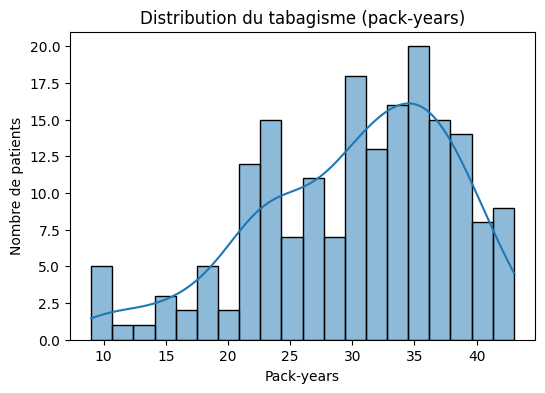

In [14]:
plt.figure(figsize=(6,4))
sns.histplot(df["tabagisme_paquets_annee"], bins=20, kde=True)

plt.title("Distribution du tabagisme (pack-years)")
plt.xlabel("Pack-years")
plt.ylabel("Nombre de patients")

plt.show()

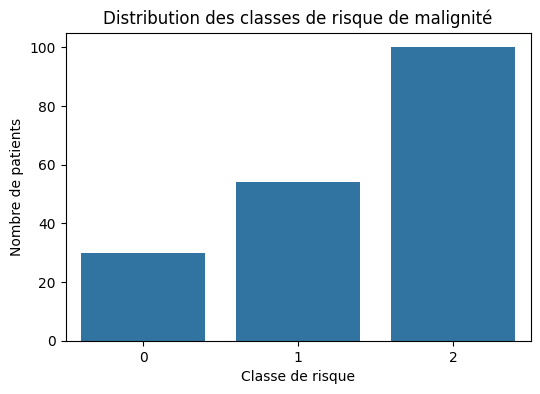

In [15]:
plt.figure(figsize=(6,4))

sns.countplot(x="risque_malignite", data=df)

plt.title("Distribution des classes de risque de malignité")
plt.xlabel("Classe de risque")
plt.ylabel("Nombre de patients")

plt.show()

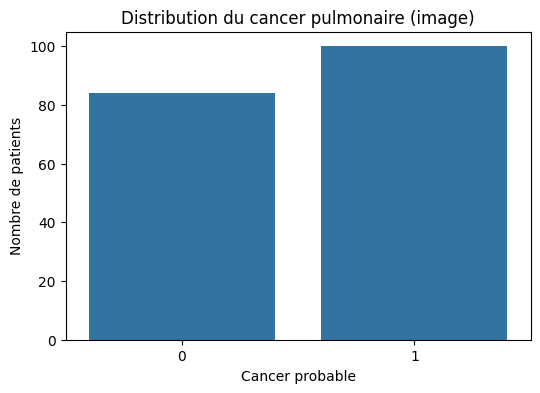

In [16]:
plt.figure(figsize=(6,4))

sns.countplot(x="cancer_image", data=df)

plt.title("Distribution du cancer pulmonaire (image)")
plt.xlabel("Cancer probable")
plt.ylabel("Nombre de patients")

plt.show()

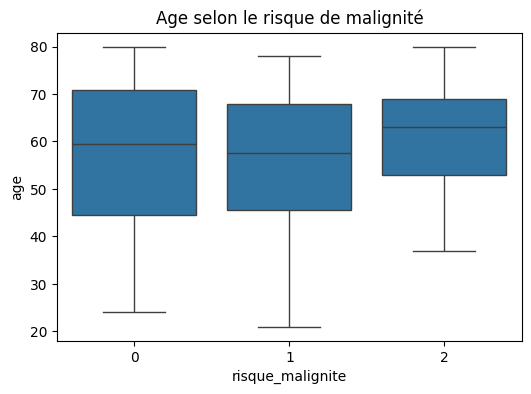

In [17]:
plt.figure(figsize=(6,4))

sns.boxplot(x="risque_malignite", y="age", data=df)

plt.title("Age selon le risque de malignité")

plt.show()

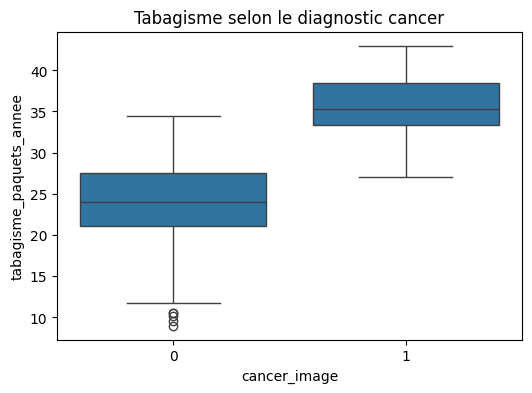

In [18]:
plt.figure(figsize=(6,4))

sns.boxplot(x="cancer_image", y="tabagisme_paquets_annee", data=df)

plt.title("Tabagisme selon le diagnostic cancer")

plt.show()

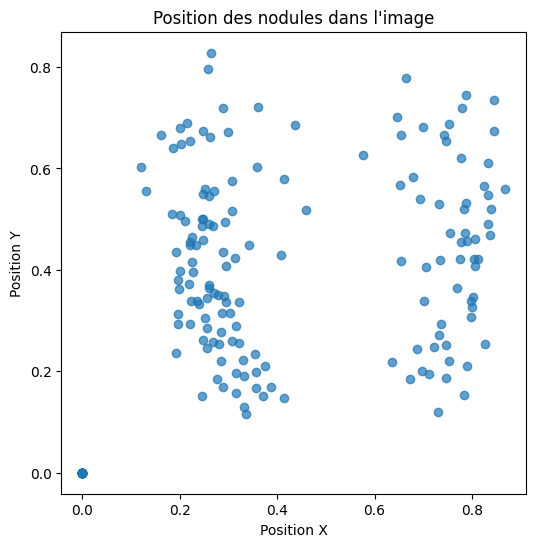

In [20]:
plt.figure(figsize=(6,6))

plt.scatter(df["x_nodule_norm"], df["y_nodule_norm"], alpha=0.7)

plt.title("Position des nodules dans l'image")
plt.xlabel("Position X")
plt.ylabel("Position Y")

plt.show()

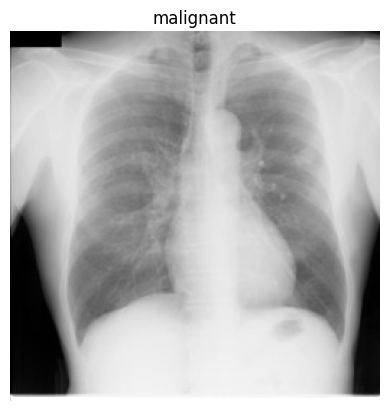

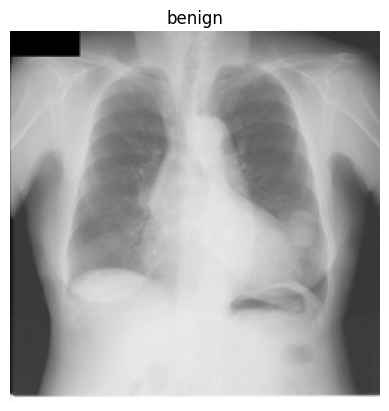

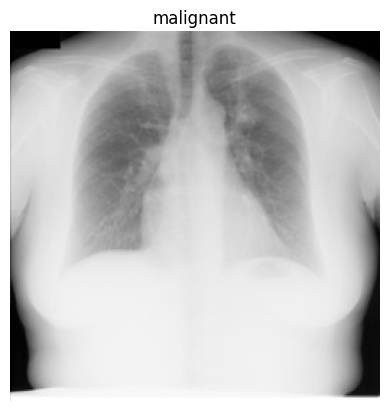

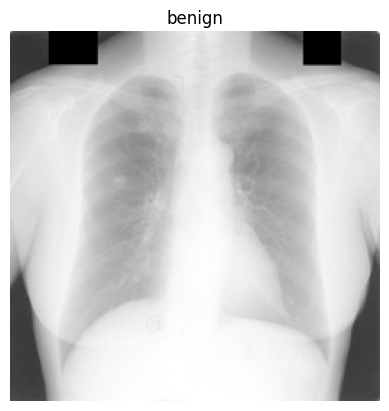

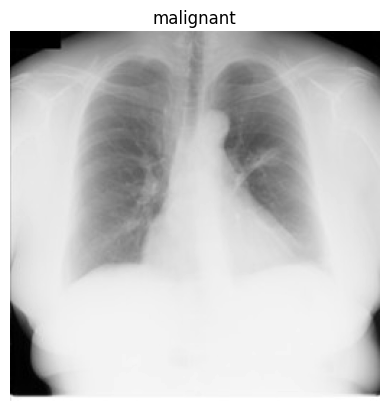

In [21]:
for i in range(5):

    img_path = df["image_path"][i]

    img = Image.open(img_path)

    plt.imshow(img, cmap="gray")
    plt.title(df["diagnostic_source"][i])
    plt.axis("off")

    plt.show()

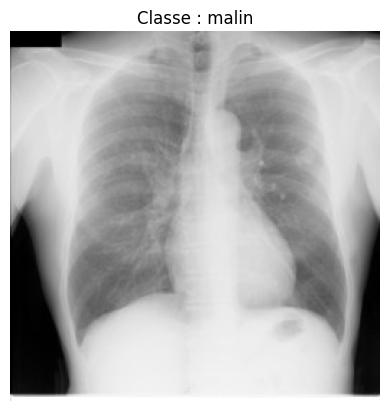

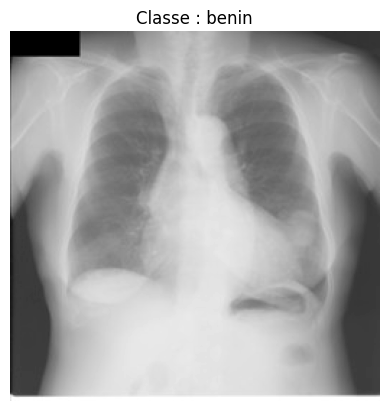

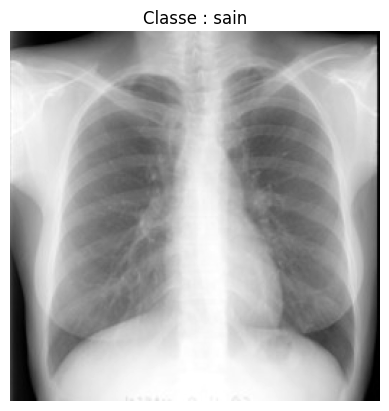

In [22]:
classes = df["classe_jsrt_source"].unique()

for c in classes:

    sample = df[df["classe_jsrt_source"] == c].iloc[0]

    img = Image.open(sample["image_path"])

    plt.imshow(img, cmap="gray")
    plt.title("Classe : " + c)
    plt.axis("off")

    plt.show()

In [25]:
numeric_columns = df.select_dtypes(include=['int64','float64']).columns

print(numeric_columns)

Index(['age', 'sexe_masculin', 'presence_nodule', 'subtilite_nodule',
       'taille_nodule_px', 'x_nodule_norm', 'y_nodule_norm',
       'tabagisme_paquets_annee', 'toux_chronique', 'dyspnee',
       'douleur_thoracique', 'perte_poids', 'spo2', 'antecedent_familial',
       'risque_malignite', 'cancer_image'],
      dtype='object')


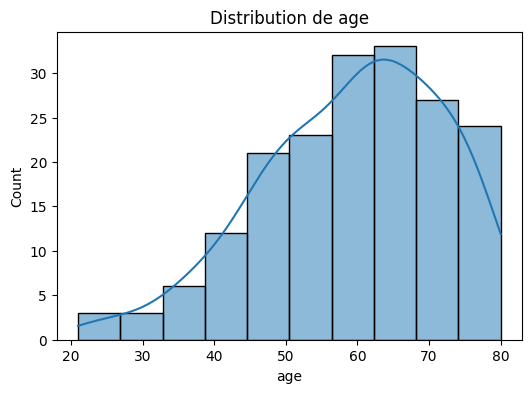

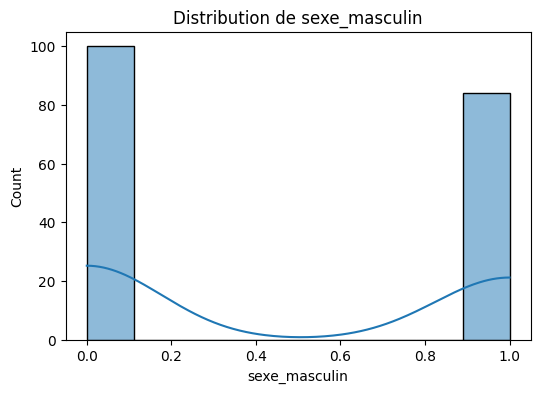

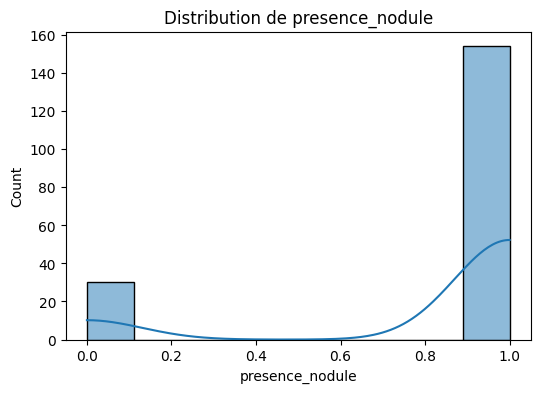

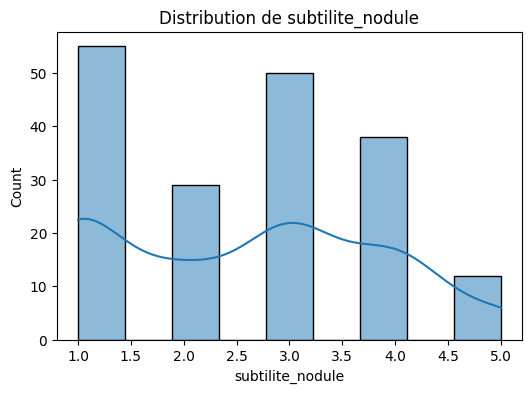

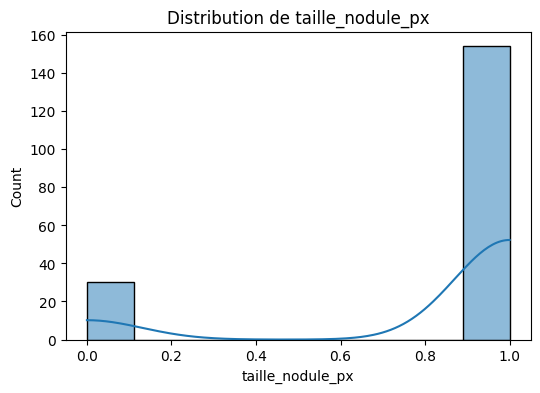

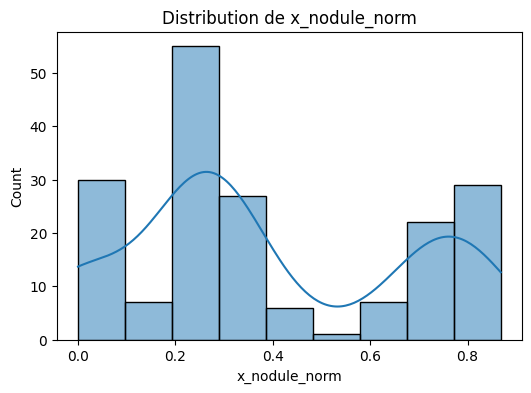

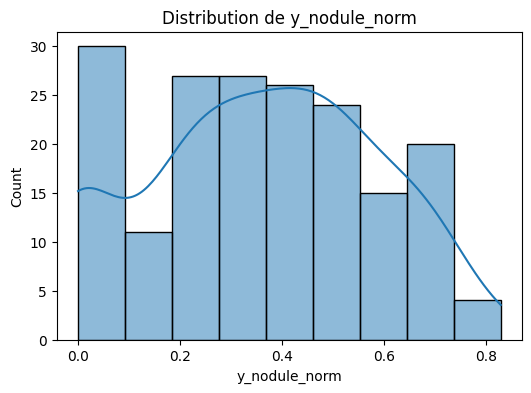

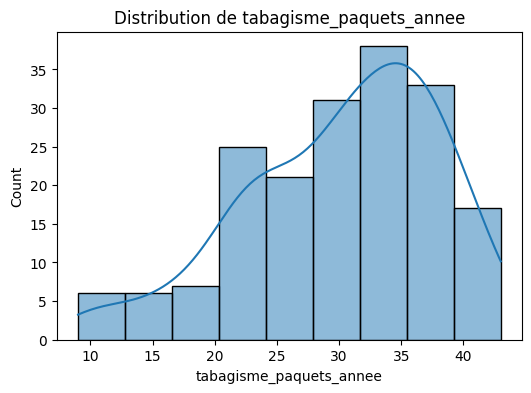

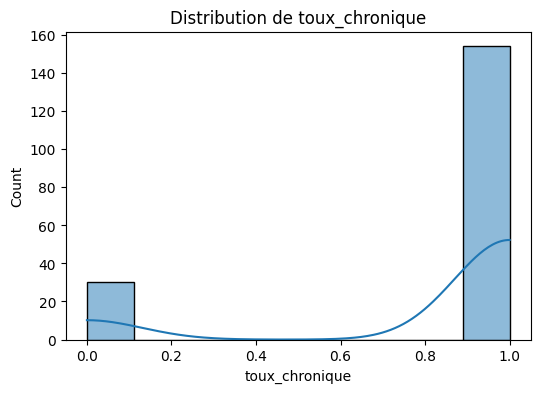

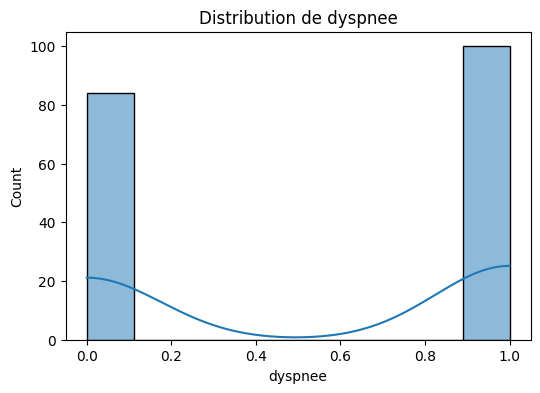

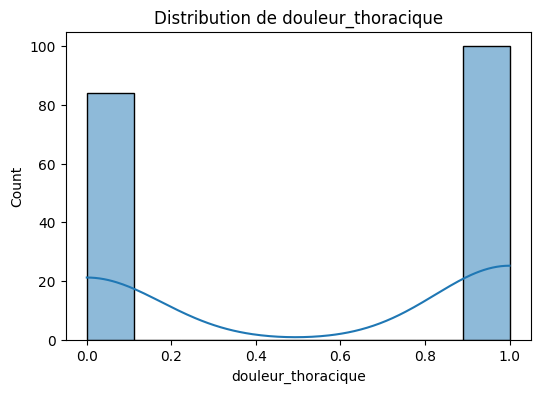

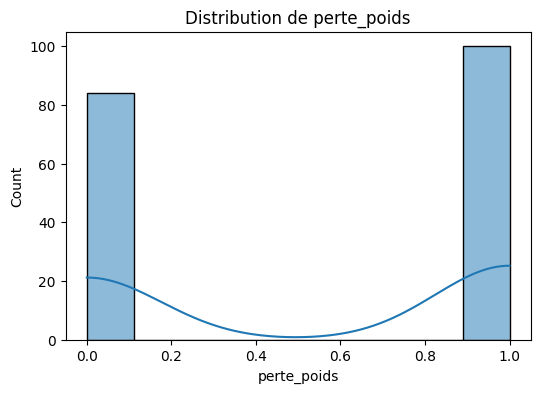

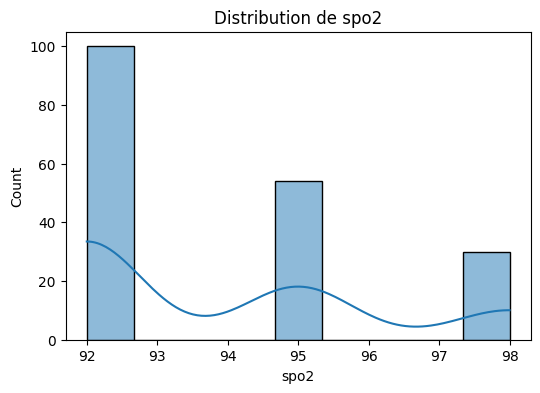

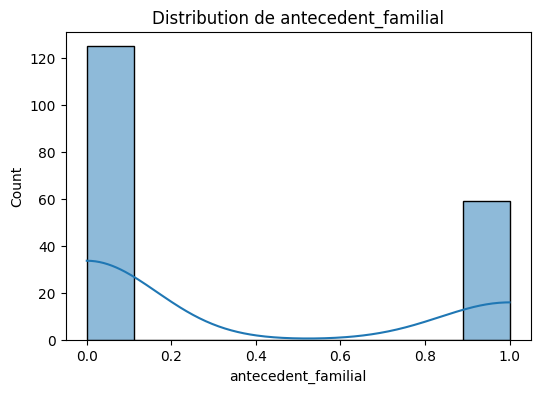

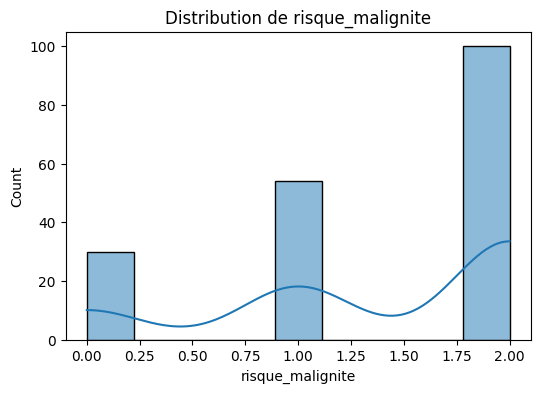

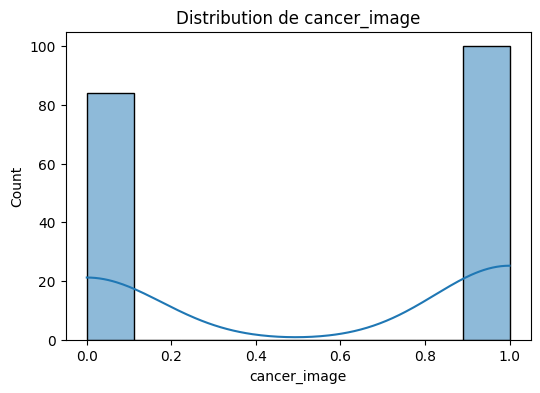

In [26]:
for col in numeric_columns:
    
    plt.figure(figsize=(6,4))
    
    sns.histplot(df[col], kde=True)
    
    plt.title(f"Distribution de {col}")
    
    plt.show()

[+] Matrice de corrélation (Spearman) :
                              age  sexe_masculin  presence_nodule  \
age                      1.000000       0.022811         0.065674   
sexe_masculin            0.022811       1.000000        -0.068062   
presence_nodule          0.065674      -0.068062         1.000000   
subtilite_nodule         0.129844      -0.047029         0.552735   
taille_nodule_px         0.065674      -0.068062         1.000000   
x_nodule_norm           -0.029132       0.087908         0.641254   
y_nodule_norm            0.005378      -0.036130         0.641242   
tabagisme_paquets_annee  0.586037       0.148436         0.590894   
toux_chronique           0.065674      -0.068062         1.000000   
dyspnee                  0.162350      -0.101905         0.481571   
douleur_thoracique       0.162350      -0.101905         0.481571   
perte_poids              0.162350      -0.101905         0.481571   
spo2                    -0.151583       0.103858        -0.7109

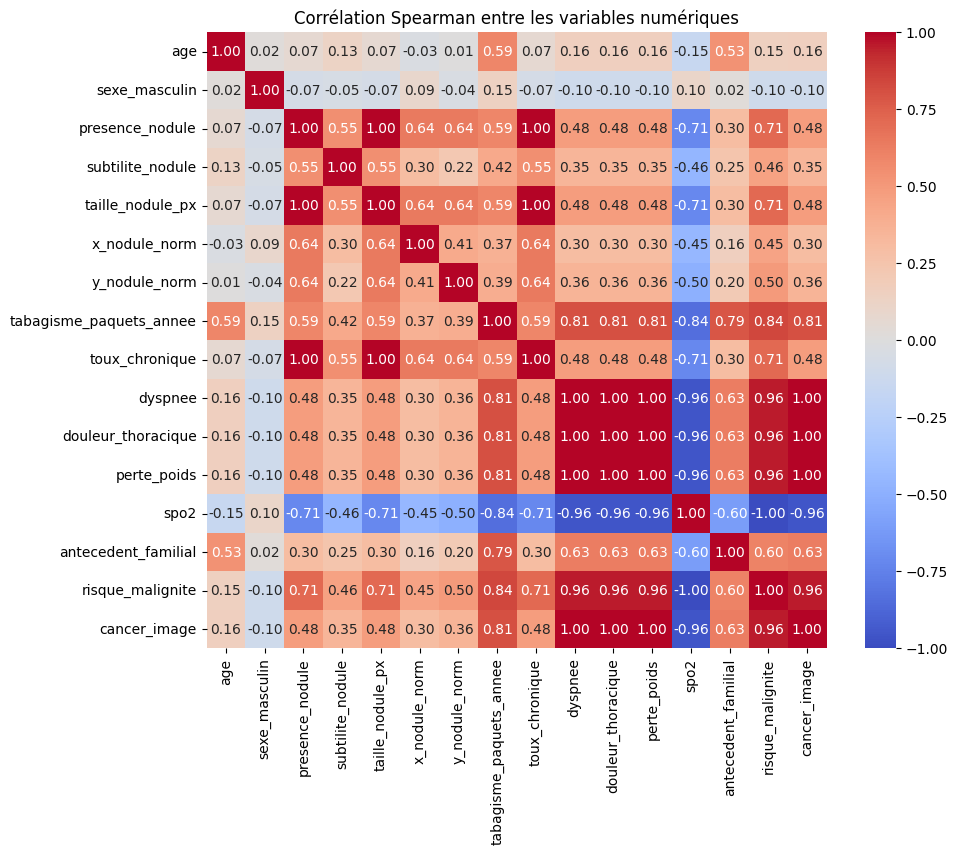

In [30]:
# la correlation

# Colonnes numériques à tester pour la corrélation
numeric_cols = [
    'age',
    'sexe_masculin',
    'presence_nodule',
    'subtilite_nodule',
    'taille_nodule_px',
    'x_nodule_norm',
    'y_nodule_norm',
    'tabagisme_paquets_annee',
    'toux_chronique',
    'dyspnee',
    'douleur_thoracique',
    'perte_poids',
    'spo2',
    'antecedent_familial',
    'risque_malignite',
    'cancer_image'
]

# Corrélation de Spearman (robuste aux distributions non normales)
corr_matrix = df[numeric_cols].corr(method='spearman')

# Affichage de la matrice de corrélation
print("[+] Matrice de corrélation (Spearman) :")
print(corr_matrix)

# Heatmap pour visualiser
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')

plt.title("Corrélation Spearman entre les variables numériques")
plt.show()

variable cible (target) est :

cancer_image

age
sexe_masculin
presence_nodule
subtilite_nodule
taille_nodule_px
x_nodule_norm
y_nodule_norm
tabagisme_paquets_annee
toux_chronique
dyspnee
antecedent_familial
spo2

Variables à SUPPRIMER
1️⃣ Variables identiques (corrélation = 1)

Ces variables donnent exactement la même information que dyspnee :

douleur_thoracique
perte_poids

Variable qui peut créer du data leakage
risque_malignite

Elle est trop corrélée avec le diagnostic.

Variables inutiles pour le modèle tabulaire
patient_id
classe_jsrt_source
diagnostic_source
image_path
patient_id → identifiant
classe_jsrt_source → information de dataset
diagnostic_source → doublon du diagnostic
image_path → utilisé seulement pour le modèle CNN

✔️ GARDER
age
sexe_masculin
presence_nodule
subtilite_nodule
taille_nodule_px
x_nodule_norm
y_nodule_norm
tabagisme_paquets_annee
toux_chronique
dyspnee
antecedent_familial
spo2
cancer_image
❌ SUPPRIMER
patient_id
douleur_thoracique
perte_poids
risque_malignite
classe_jsrt_source
diagnostic_source
image_path

In [42]:
# colonnes à supprimer
cols_to_drop = [
    'patient_id',
    'douleur_thoracique',
    'perte_poids',
    'classe_jsrt_source',
    'diagnostic_source',
    'image_path',
    'spo2',
    'dyspnee'
]

df_clean = df.drop(columns=cols_to_drop)

print("Shape du dataset après nettoyage :", df_clean.shape)
df_clean.head()

Shape du dataset après nettoyage : (184, 12)


,age,sexe_masculin,presence_nodule,subtilite_nodule,taille_nodule_px,x_nodule_norm,y_nodule_norm,tabagisme_paquets_annee,toux_chronique,antecedent_familial,risque_malignite,cancer_image
0,53,1,1,5,1,0.7979,0.3379,34.9,1,0,2,1
1,78,0,1,5,1,0.7881,0.5322,31.4,1,0,1,0
2,63,0,1,5,1,0.6362,0.2183,34.9,1,1,2,1
3,68,0,1,5,1,0.2959,0.4082,28.4,1,0,1,0
4,73,0,1,5,1,0.7021,0.3379,37.9,1,1,2,1


In [43]:
# Variables explicatives
X = df_clean.drop(columns=['risque_malignite','cancer_image'])

# Variable cible
y = df_clean['risque_malignite']

print("Shape de X :", X.shape)
print("Shape de y :", y.shape)

Shape de X : (184, 10)
Shape de y : (184,)


In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train :", X_train.shape)
print("Test :", X_test.shape)

Train : (147, 10)
Test : (37, 10)


In [46]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [47]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(max_iter=1000)

model_lr.fit(X_train_scaled, y_train)

y_pred_lr = model_lr.predict(X_test_scaled)

In [48]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

In [49]:
from sklearn.ensemble import GradientBoostingClassifier

model_gb = GradientBoostingClassifier()

model_gb.fit(X_train, y_train)

y_pred_gb = model_gb.predict(X_test)

In [50]:
from sklearn.metrics import classification_report, accuracy_score

print("===== Logistic Regression =====")
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

print("===== Random Forest =====")
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

print("===== Gradient Boosting =====")
print("Accuracy :", accuracy_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

===== Logistic Regression =====
Accuracy : 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00        11
           2       1.00      1.00      1.00        20

    accuracy                           1.00        37
   macro avg       1.00      1.00      1.00        37
weighted avg       1.00      1.00      1.00        37

===== Random Forest =====
Accuracy : 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00        11
           2       1.00      1.00      1.00        20

    accuracy                           1.00        37
   macro avg       1.00      1.00      1.00        37
weighted avg       1.00      1.00      1.00        37

===== Gradient Boosting =====
Accuracy : 0.9459459459459459
              precision    recall  f1-score   support

           0       1.00      1.00  

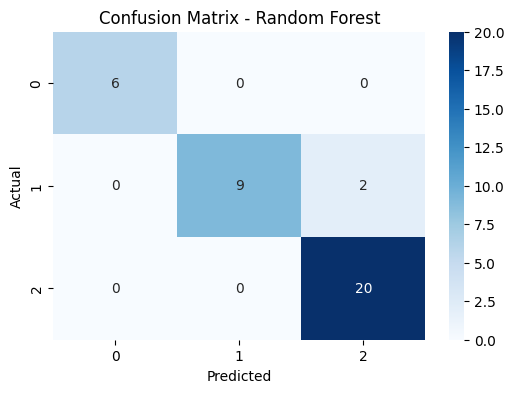

In [54]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_gb)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")

plt.show()

In [55]:
import joblib

joblib.dump(model_gb, "modele_tabulaire.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [57]:
# Probabilités par classe
proba = model_gb.predict_proba(X_test)

print(proba[:5])

[[8.54838312e-07 1.76034836e-05 9.99981542e-01]
 [5.71971569e-07 4.74797145e-06 9.99994680e-01]
 [5.86728694e-07 9.51210501e-06 9.99989901e-01]
 [3.32562507e-06 9.99980372e-01 1.63024441e-05]
 [1.68458557e-05 2.58848394e-01 7.41134761e-01]]
